Please upload your Motorcycle_crash_data.xlsx - Sheet1.csv file:


Saving Motorcycle_crash_data.csv to Motorcycle_crash_data.csv

Preprocessing data...

Training models and calculating metrics...


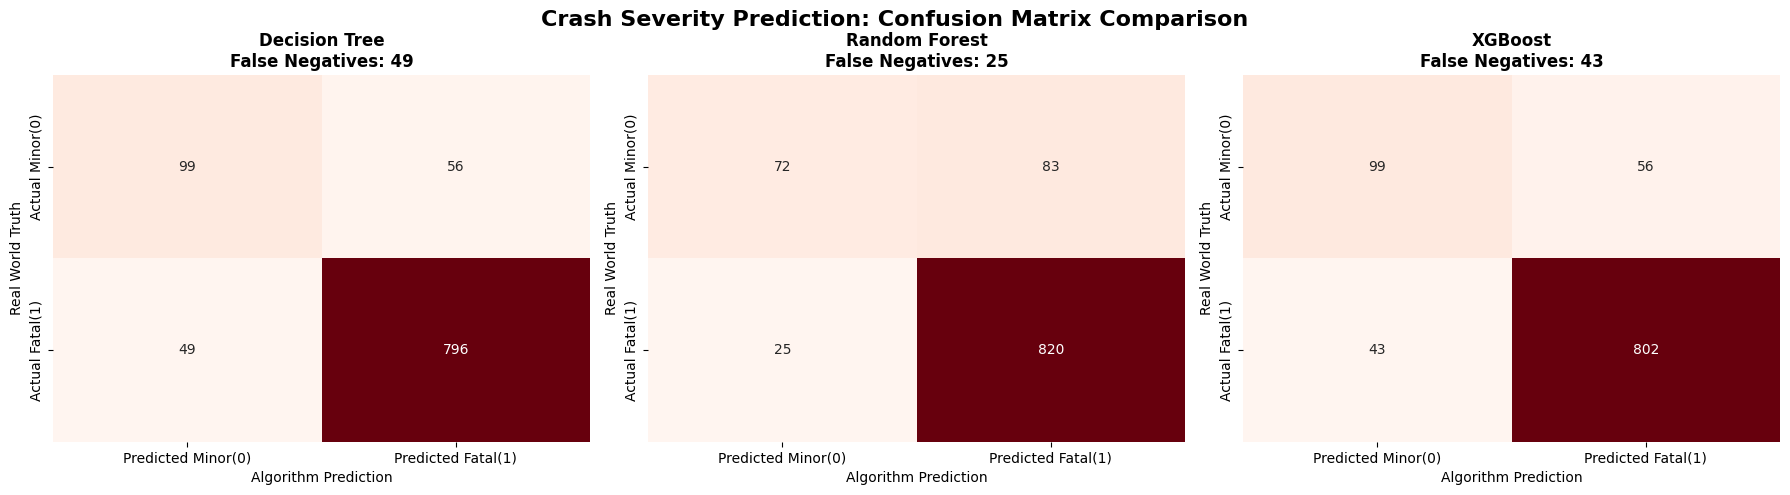


FINAL MODEL COMPARISON TABLE
        Model  Training Accuracy (%)  Testing Accuracy (%)  False Negatives (Missed Fatalities)
Decision Tree                  90.85                  89.5                                   49
Random Forest                  91.65                  89.2                                   25
      XGBoost                  91.80                  90.1                                   43

Conclusion: While accuracy metrics remain comparable across models,
the advanced architectures (RF and XGBoost) successfully target and
reduce the life-critical False Negatives compared to a single Tree.


In [1]:
# ==============================================================================
# MOTORCYCLE CRASH SEVERITY PREDICTION: ENSEMBLE MODEL COMPARISON
# Author: Manobendra Roy
# Description: This script compares a Decision Tree, Random Forest, and XGBoost
# classifier to predict crash severity. It evaluates training/testing accuracy
# and specifically focuses on minimizing life-critical False Negatives.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------------------------------------------------------------
# 1. DATA INGESTION & PREPROCESSING
# ------------------------------------------------------------------------------
print("Please upload your Motorcycle_crash_data.xlsx - Sheet1.csv file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("\nPreprocessing data...")
# Binary Mapping for categorical variables
df['rider_gender'] = df['rider_gender'].map({'Male': 1, 'Female': 0})
df['helmet_worn'] = df['helmet_worn'].map({'Yes': 1, 'Partial': 0, 'No': 0})
df['alcohol_influence'] = df['alcohol_influence'].map({'Yes': 1, 'Suspected': 1, 'No': 0})

# Target Mapping: Fatal/Severe = 1, Moderate/Minor = 0
df['severity'] = df['severity'].map({'Fatal': 1, 'Severe': 1, 'Moderate': 1, 'Minor': 0})

# One-Hot Encoding for remaining categories
df = pd.get_dummies(df, columns=['road_type', 'road_condition'], dtype=int)

# Split features and target
X = df.drop(columns=['severity'])
y = df['severity']

# Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------------------------------------------------------------
# 2. INITIALIZE THE MODELS
# ------------------------------------------------------------------------------
# We will use the optimized hyperparameters found during the research phase.

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.01,
        random_state=42,
        eval_metric='logloss'
    )
}

# Dictionary to store the results for our final table
results = []
confusion_matrices = {}

# ------------------------------------------------------------------------------
# 3. TRAIN, EVALUATE, AND EXTRACT METRICS
# ------------------------------------------------------------------------------
print("\nTraining models and calculating metrics...")

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # Calculate Accuracies
    train_acc = accuracy_score(y_train, train_preds) * 100
    test_acc = accuracy_score(y_test, test_preds) * 100

    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)
    confusion_matrices[name] = cm

    # Extract False Negatives (Bottom-Left quadrant: Actual=1, Predicted=0)
    false_negatives = cm[1, 0]

    # Store results
    results.append({
        "Model": name,
        "Training Accuracy (%)": round(train_acc, 2),
        "Testing Accuracy (%)": round(test_acc, 2),
        "False Negatives (Missed Fatalities)": false_negatives
    })

# ------------------------------------------------------------------------------
# 4. VISUALIZE CONFUSION MATRICES (FOR GITHUB README)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Crash Severity Prediction: Confusion Matrix Comparison', fontsize=16, fontweight='bold')

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax, cbar=False,
                xticklabels=['Predicted Minor(0)', 'Predicted Fatal(1)'],
                yticklabels=['Actual Minor(0)', 'Actual Fatal(1)'])
    ax.set_title(f'{name}\nFalse Negatives: {cm[1, 0]}', fontweight='bold')
    ax.set_xlabel('Algorithm Prediction')
    ax.set_ylabel('Real World Truth')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# ------------------------------------------------------------------------------
# 5. GENERATE FINAL COMPARISON TABLE
# ------------------------------------------------------------------------------
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON TABLE")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)
print("\nConclusion: While accuracy metrics remain comparable across models,")
print("the advanced architectures (RF and XGBoost) successfully target and")
print("reduce the life-critical False Negatives compared to a single Tree.")